## Setup: import libraries and functions

In [1]:
from argovisHelpers import helpers as avh
from argovisHelpers import analysis as ava
import matplotlib.pyplot as plt
import gsw
import gsw_xarray
import xarray as xr
import cartopy.crs as ccrs
import numpy as np
import numpy
import pandas as pd
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

APIKEY  = 'guest'
APIROOT = 'https://argovis-api.colorado.edu/'

### Import helper functions
`plot_maps` — scatter profile locations on a map.  
`compare_profiles` — plot individual or mean vertical profiles (to plot means, pre-average with `average_profiles_dict` and pass `mean_style=True`).  
`plot_profiles_TSdiagram` — T/S diagram with optional coloring by a third variable (pressure, time, or any scalar).  
`average_profiles_dict` — compute level-by-level mean profiles across a list of Profile objects, returned as a single-entry dict ready for `compare_profiles`.  
`profiles_to_xarray` *(optional)* — convert a list of Profile objects into an `xarray.Dataset` with pressure levels as a coordinate.

In [3]:
from functions import plot_maps, compare_profiles, plot_profiles_TSdiagram, average_profiles_dict
# OPTIONAL
from functions import profiles_to_xarray

## Setup: configuration
Uncomment one collection block below. All cells in the notebook read from these variables — nothing else needs to be changed.

In [4]:
# ── Query ─────────────────────────────────────────────────────────────────────
START_DATE = '2020-01-01T00:00:00Z'
END_DATE   = '2020-03-31T00:00:00Z'
BOX        = [[-150, 45], [-145, 50]]

# ── Collection (uncomment one block) ──────────────────────────────────────────

COLLECTION = 'argo'
# VARIABLES  = ['temperature', 'salinity', 'pressure']
VARIABLES  = ['temperature,1', 'salinity,1', 'pressure,1']  # Argo: select only QC-flagged-good data (flag=1)
TEMP_VAR   = 'temperature'
SALT_VAR   = 'salinity'

# NOTE: CCHDO is ship-based hydrography with sparse coverage.
# If you get 0 profiles, try widening the time range (e.g., 2010–2023)
# or the bounding box. Q1 2020 in the Gulf of Alaska has no CCHDO data.
# COLLECTION = 'cchdo'
# VARIABLES  = ['temperature', 'salinity', 'pressure']
# TEMP_VAR   = 'temperature'
# SALT_VAR   = 'salinity'

# NOTE: Easy Ocean is repeat-hydrography based, with limited spatiotemporal coverage.
# If you get 0 profiles, try widening the time range or bounding box.
# COLLECTION = 'easyocean'
# VARIABLES  = ['ctd_temperature', 'ctd_salinity', 'pressure']
# TEMP_VAR   = 'ctd_temperature'
# SALT_VAR   = 'ctd_salinity'

# ── Interpolation levels ───────────────────────────────────────────────────────
INTERPOLATION_LEVELS = avh.rg_levels()   # default RG levels
# INTERPOLATION_LEVELS = np.arange(10, 210, 10)  # custom levels

# ── GLODAP ────────────────────────────────────────────────────────────────────
# GLODAP is included by default as a climatological reference.
# Set to False to skip it.
INCLUDE_GLODAP = True

# Maximum pressure shown on all depth-axis plots.
# Comment out to plot full depth range.
DEPTH_YLIM = 1000  # dbar
# DEPTH_YLIM = None

## Setup: plotting conventions
**Color** is assigned per dataset/collection via `DATASET_COLORS`, keyed by collection name.  
`MARKER` and `LINESTYLE` are single-element lists because the plotting functions expect lists (e.g. to distinguish multiple time periods with different markers or linestyles).

In [5]:
DATASET_COLORS = {
    'argo'     : 'red',
    'cchdo'    : 'green',
    'easyocean': 'darkblue',
}

# Single time period / region defaults
MARKER    = ['o']
LINESTYLE = ['-']

## Load data
Query the selected collection via the Argovis API. Depending on the region and time period this may take a moment. `queryProfile` returns `Profile` objects directly and is the preferred query for profile data.

In [6]:
options = {
    'startDate': START_DATE,
    'endDate'  : END_DATE,
    'box'      : BOX,
    'data'     : ','.join(VARIABLES),
}

profiles = avh.queryProfile(COLLECTION, options=options, apikey=APIKEY, apiroot=APIROOT)
print(f"Fetched {len(profiles)} profiles from {COLLECTION}")

Fetched 48 profiles from argo


## Derived quantities
### GSW: absolute salinity, conservative temperature, potential density, MLD

Computed per profile using the GSW toolbox on the **raw profiles**, before interpolation. This ensures GSW variables are carried through `interpolate_all` automatically and are available in `profiles_interp` and `profiles_mean` for all subsequent plots.

Estimating derived variables requires both `TEMP_VAR` and `SALT_VAR` to be present.

In [7]:
for p in profiles:
    if not p.hasvar(SALT_VAR) or not p.hasvar(TEMP_VAR):
        continue

    SA = gsw.conversions.SA_from_SP(
        p.getvar(SALT_VAR), p.getvar('pressure'), p.longitude, p.latitude)
    p.setvar('absolute_salinity', SA)

    p.setvar('potential_temperature',
        gsw.conversions.pt0_from_t(SA, p.getvar(TEMP_VAR), p.getvar('pressure')))

    CT = gsw.conversions.CT_from_t(SA, p.getvar(TEMP_VAR), p.getvar('pressure'))
    p.setvar('conservative_temperature', CT)

    p.setvar('density',
        gsw.rho(SA, CT, p.getvar('pressure')))

    sigma0 = gsw.sigma0(SA, CT) + 1000
    p.setvar('potential_density', sigma0)

    p.setvar('MLD',
        [ava.MLD_estimate(p.getvar('pressure'), sigma0, 0.03)][0])

print("GSW variables computed: absolute_salinity, potential_temperature, "
      "conservative_temperature, density, potential_density, MLD")

GSW variables computed: absolute_salinity, potential_temperature, conservative_temperature, density, potential_density, MLD


## Interpolation
Raw profiles are interpolated onto `INTERPOLATION_LEVELS`. GSW-derived variables are carried through automatically since `interpolate_all` processes all variables present in the Profile object.

Individual profile plots use raw profiles (original pressure levels); mean profile plots require interpolated profiles so all profiles share the same vertical levels.

In [8]:
profiles_interp = [ava.interpolate_all(p, INTERPOLATION_LEVELS) for p in profiles]

print(f"Raw profiles:          {len(profiles)}")
print(f"Interpolated profiles: {len(profiles_interp)}")

Raw profiles:          48
Interpolated profiles: 48


## Xarray conversion (optional)
Convert interpolated profiles to an `xr.Dataset`. All profile-level variables become `(index, levels)` arrays; scalars (including MLD) become `(index,)` arrays. Use `profiles_interp` for the interpolated grid or `profiles` for original levels.

In [9]:
ds = profiles_to_xarray(profiles_interp)
# print(ds)

### Horizontal profile average
`average_profiles_dict` — compute the horizontal mean across profiles for each dataset. Takes a dict of the same shape as the profile dicts used throughout the notebook and returns a dict with one averaged `Profile` per dataset, ready to pass directly to `compare_profiles` with `mean_style=True`.

> **On averaging behaviour:** by default, `average_profiles_dict` uses `np.mean`, so a level is only included in the mean if **all** profiles have a valid value at that level. This ensures the mean profile is the average of a consistent set of profiles at every depth — levels where any profile has a NaN are excluded entirely.
>
> If you prefer to retain shallower or deeper levels even when only a subset of profiles reach them, pass `use_nanmean=True`. Be aware that in that case the number of profiles contributing to the mean varies with depth.

In [10]:
profiles_mean = average_profiles_dict({COLLECTION: profiles_interp})

## Visualization
### Map of profile locations

/usr/local/lib/python3.9/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


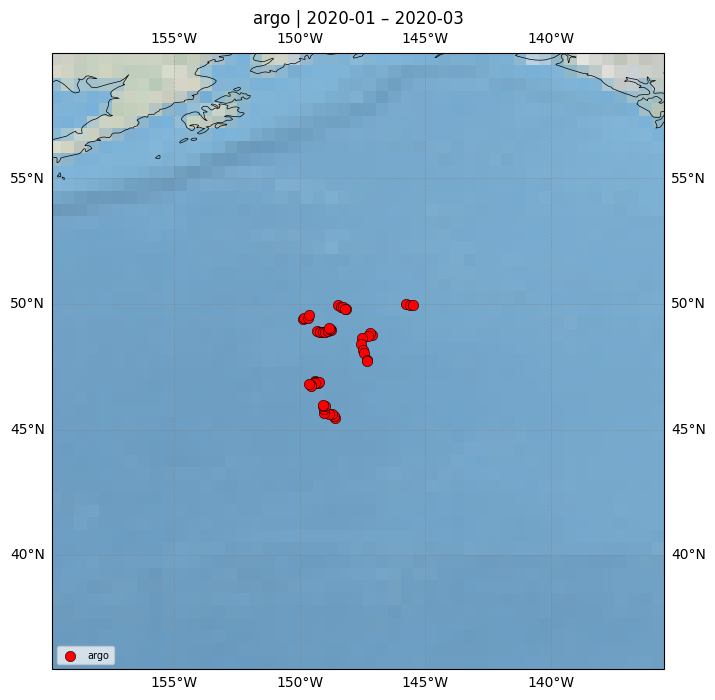

<GeoAxes: title={'center': 'argo | 2020-01 – 2020-03'}>

In [11]:
plot_maps(
    [[p.latitude  for p in profiles]],
    [[p.longitude for p in profiles]],
    title=f'{COLLECTION} | {START_DATE[:7]} – {END_DATE[:7]}',
    labels=[f'{COLLECTION}'],
    colors=[DATASET_COLORS.get(COLLECTION, 'steelblue')],
    markers=MARKER,
)

## Visualization
### Individual profiles

All profiles in the query, plotted on their original pressure levels.

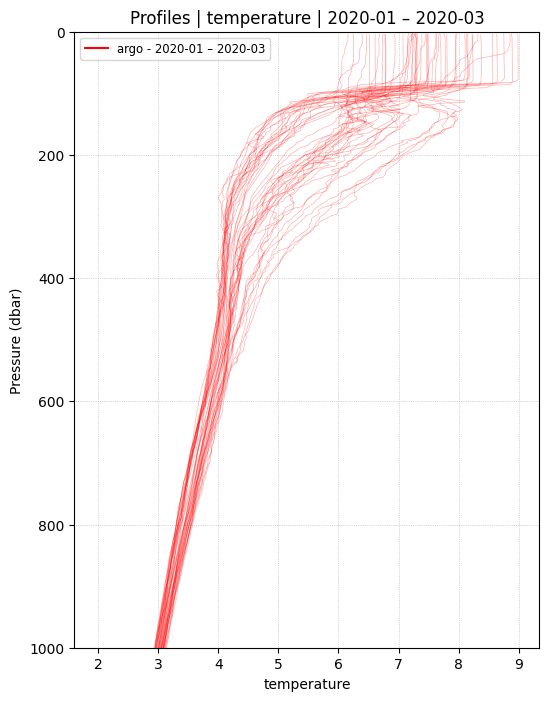

In [12]:
compare_profiles(
    {COLLECTION: profiles},
    varname=TEMP_VAR,
    dataset_colors=DATASET_COLORS,
    time_linestyles=LINESTYLE,
    depth_ylim=DEPTH_YLIM,
    dataset=COLLECTION,
    datestring=f"{START_DATE[:7]} – {END_DATE[:7]}",
    mean_style=False,
)

## Visualization
### Mean profiles

Average vertical profiles on the common interpolation grid, using `profiles_mean`. `compare_profiles` plots one variable at a time — the loop below runs it for a selection of variables. Edit `vars_to_plot` to add, remove, or reorder variables. To show markers, pass `markevery=1` (every level) or `markevery=5` (every 5th level), and optionally `markersize=3`.

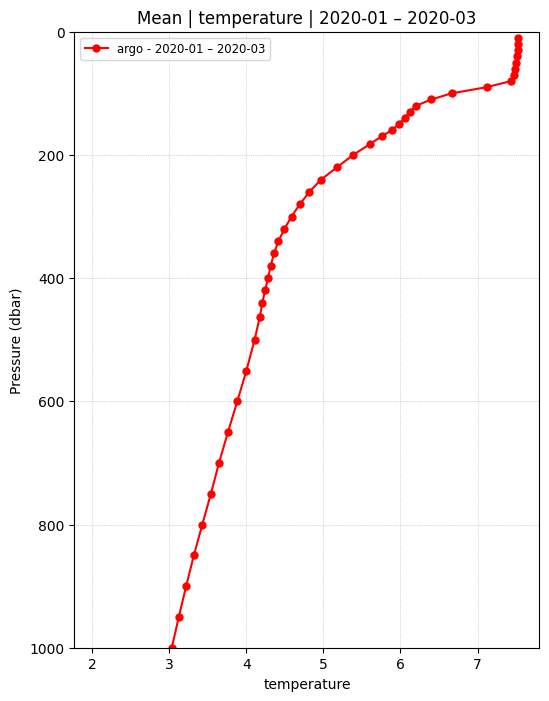

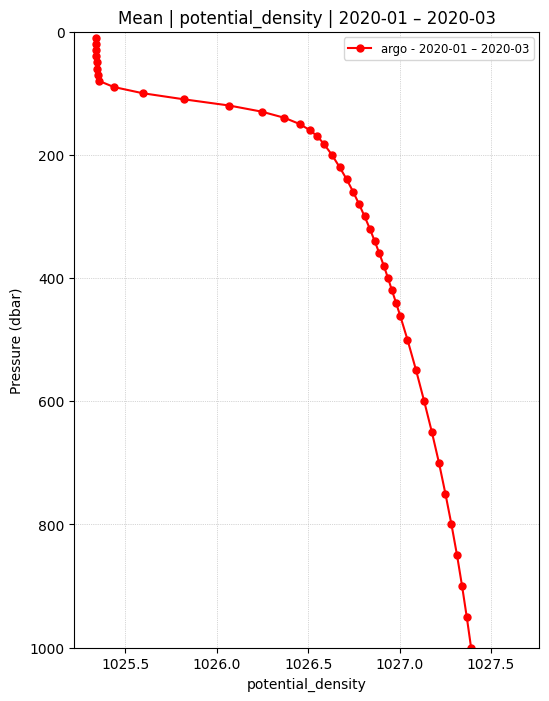

In [13]:
vars_to_plot = [TEMP_VAR, 'potential_density']

for var in vars_to_plot:
    compare_profiles(
        profiles_mean,
        varname=var,
        dataset_colors=DATASET_COLORS,
        time_linestyles=LINESTYLE,
        depth_ylim=DEPTH_YLIM,
        dataset=COLLECTION,
        datestring=f"{START_DATE[:7]} – {END_DATE[:7]}",
        mean_style=True,
        markevery=1,
        markersize=5
    )

## Visualization
### T/S diagrams

Three versions of the same diagram: no coloring, colored by pressure, and colored by time. The `fig_settings` dict controls appearance and can be extended with `cbar_clim` to fix the colorbar range.

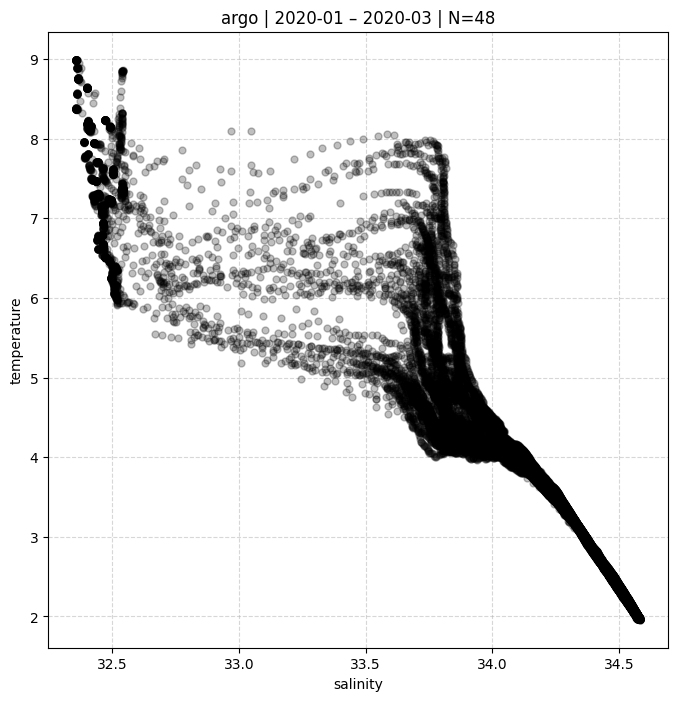

In [14]:
my_settings = {'color': 'k', 'linewidth': 1, 'linestyle': '-', 'alpha': 0.25}

valuesT = [p.getvar(TEMP_VAR) for p in profiles]
valuesS = [p.getvar(SALT_VAR) for p in profiles]

plot_profiles_TSdiagram(
    valuesT, valuesS, TEMP_VAR, SALT_VAR,
    values_to_color=None,
    title=f'{COLLECTION} | {START_DATE[:7]} – {END_DATE[:7]} | N={len(profiles)}',
    fig_settings=my_settings,
)

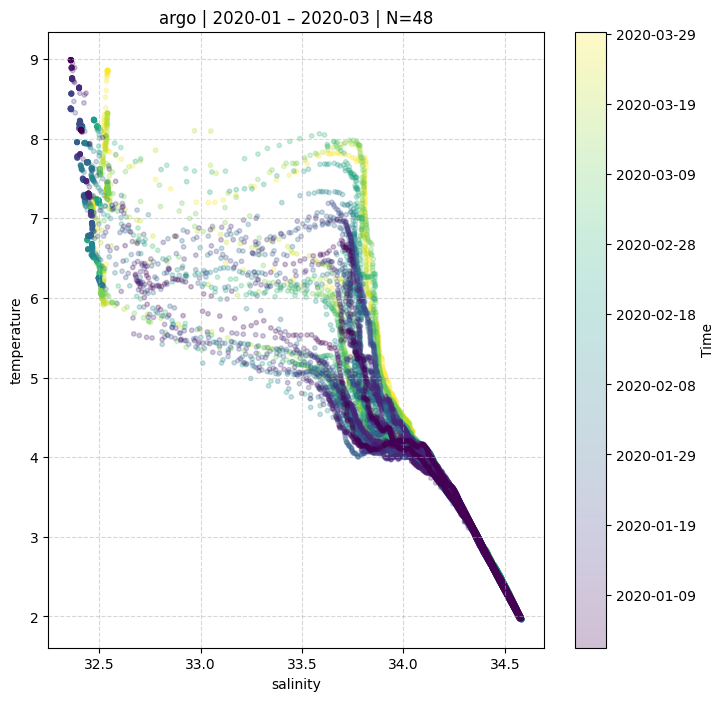

In [15]:
valuesTimestamp = [p.timestamp for p in profiles]

plot_profiles_TSdiagram(
    valuesT, valuesS, TEMP_VAR, SALT_VAR,
    values_to_color=valuesTimestamp,
    title=f'{COLLECTION} | {START_DATE[:7]} – {END_DATE[:7]} | N={len(profiles)}',
    fig_settings=my_settings | {'cbar_label': 'Time'},
)

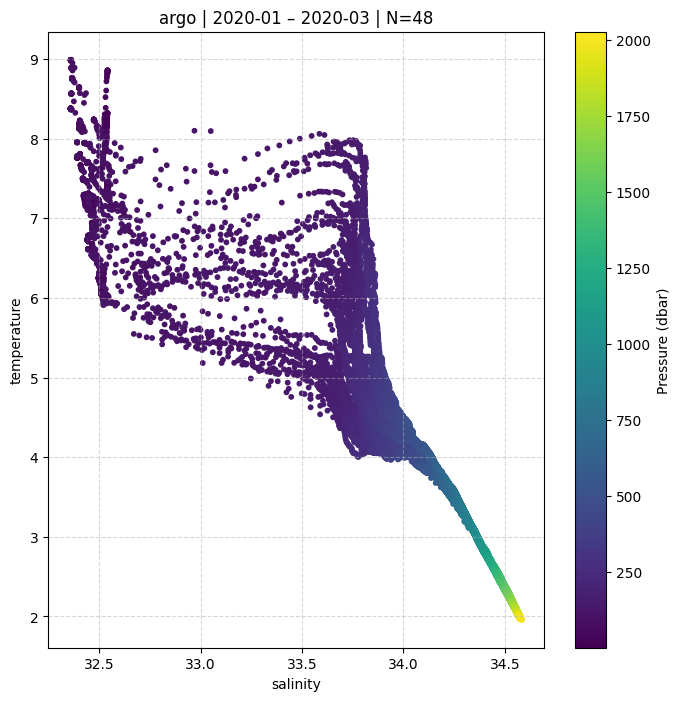

In [16]:
vertical = [p.getvar('pressure') for p in profiles]

plot_profiles_TSdiagram(
    valuesT, valuesS, TEMP_VAR, SALT_VAR,
    values_to_color=vertical,
    title=f'{COLLECTION} | {START_DATE[:7]} – {END_DATE[:7]} | N={len(profiles)}',
    fig_settings=my_settings | {'cbar_label': 'Pressure (dbar)', 'alpha': 1},
)

# GLODAP

GLODAP (Global Ocean Data Analysis Project) is a climatological gridded product derived from bottle data collected over decades of oceanographic cruises. It is included here as a reference climatology to compare against the in-situ profiles queried above.

In [17]:
if INCLUDE_GLODAP:
    glodap_options = {
        'startDate': '1000-01-01T00:00:00Z',
        'endDate'  : '1000-01-01T00:00:01Z',
        'box'      : BOX,
        'data'     : 'temperature,salinity',
    }
    glodap_raw = avh.queryGrid('grids/glodap', options=glodap_options, apikey=APIKEY, apiroot=APIROOT)
    print(f"Loaded: {list(glodap_raw.data_vars)}")

Loaded: ['salinity', 'temperature']


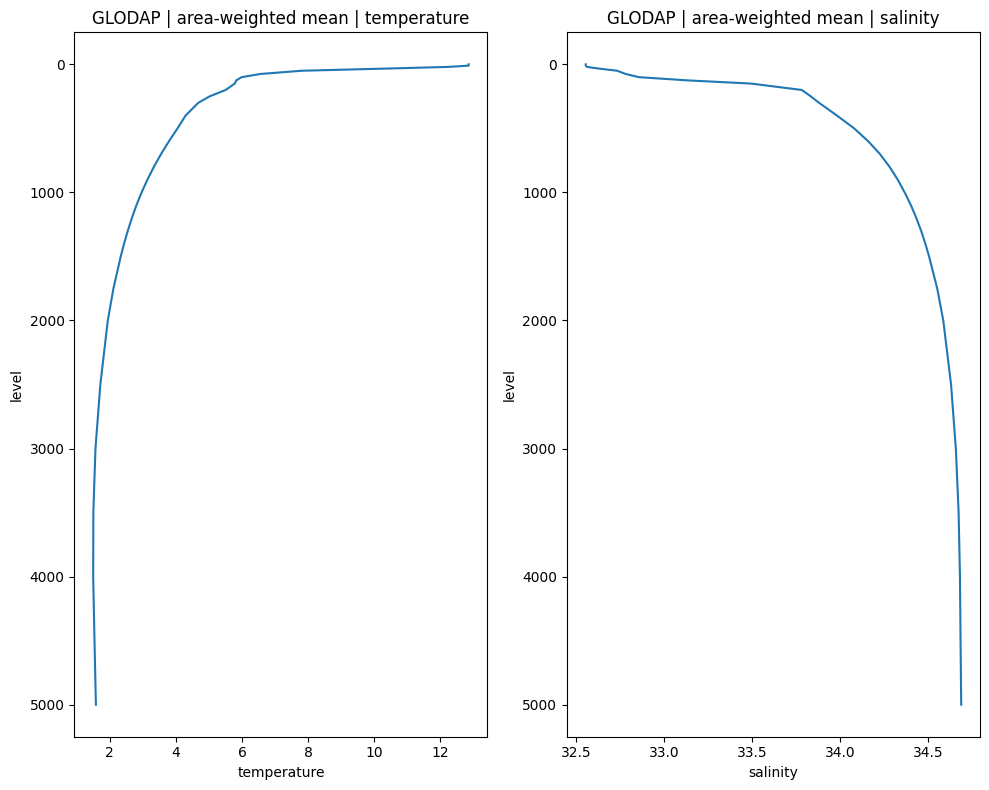

In [18]:
if INCLUDE_GLODAP:
    awm = ava.regional_mean(glodap_raw, form='area').mean(dim='timestamp')

    fig, axes = plt.subplots(1, 2, figsize=(10, 8))
    for ax, var in zip(axes, ['temperature', 'salinity']):
        awm[var].plot(y='level', ax=ax)
        ax.invert_yaxis()
        ax.set_title(f'GLODAP | area-weighted mean | {var}')

    plt.tight_layout()
    plt.show()
    plt.close()